In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls -la "/content/drive/MyDrive/PlantVillage" | sed -n '1,200p'

total 60
drwx------ 2 root root 4096 Aug 14 04:44 Pepper__bell___Bacterial_spot
drwx------ 2 root root 4096 Aug 14 04:44 Pepper__bell___healthy
drwx------ 2 root root 4096 Aug 14 04:44 Potato___Early_blight
drwx------ 2 root root 4096 Aug 14 04:44 Potato___healthy
drwx------ 2 root root 4096 Aug 14 04:44 Potato___Late_blight
drwx------ 2 root root 4096 Aug 14 04:44 Tomato_Bacterial_spot
drwx------ 2 root root 4096 Aug 14 04:44 Tomato_Early_blight
drwx------ 2 root root 4096 Aug 14 04:44 Tomato_healthy
drwx------ 2 root root 4096 Aug 14 04:44 Tomato_Late_blight
drwx------ 2 root root 4096 Aug 14 04:44 Tomato_Leaf_Mold
drwx------ 2 root root 4096 Aug 14 04:44 Tomato_Septoria_leaf_spot
drwx------ 2 root root 4096 Aug 14 04:44 Tomato_Spider_mites_Two_spotted_spider_mite
drwx------ 2 root root 4096 Aug 14 04:44 Tomato__Target_Spot
drwx------ 2 root root 4096 Aug 14 04:44 Tomato__Tomato_mosaic_virus
drwx------ 2 root root 4096 Aug 14 04:44 Tomato__Tomato_YellowLeaf__Curl_Virus


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU available nahi hai. Colab Runtime → Change runtime type → T4 GPU select karo.")

PyTorch version: 2.11.0+cpu
GPU available: False
⚠️ GPU available nahi hai. Colab Runtime → Change runtime type → T4 GPU select karo.


In [ ]:
import os

DATASET_DIR = "/content/drive/MyDrive/PlantVillage"

classes = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if folder.startswith("Tomato_")
    and os.path.isdir(os.path.join(DATASET_DIR, folder))
])

print("Total Tomato classes:", len(classes))

for i, cls in enumerate(classes, 1):
    folder_path = os.path.join(DATASET_DIR, cls)
    images = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    print(f"{i:2d}. {cls:55s} → {len(images)} images")

Total Tomato classes: 10
 1. Tomato_Bacterial_spot                                   → 2127 images
 2. Tomato_Early_blight                                     → 1001 images
 3. Tomato_Late_blight                                      → 1909 images
 4. Tomato_Leaf_Mold                                        → 952 images
 5. Tomato_Septoria_leaf_spot                               → 1787 images
 6. Tomato_Spider_mites_Two_spotted_spider_mite             → 1684 images
 7. Tomato__Target_Spot                                     → 1404 images
 8. Tomato__Tomato_YellowLeaf__Curl_Virus                   → 3208 images
 9. Tomato__Tomato_mosaic_virus                             → 373 images
10. Tomato_healthy                                          → 1591 images


## **Train/Validation/Test split**

In [ ]:
import os
import random
import pandas as pd
from sklearn.model_selection import train_test_split

DATASET_DIR = "/content/drive/MyDrive/PlantVillage"

# Tomato classes
classes = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if folder.startswith("Tomato_")
    and os.path.isdir(os.path.join(DATASET_DIR, folder))
])

print("Classes:")
for i, cls in enumerate(classes):
    print(i, "→", cls)

# Create dataframe
data = []

valid_extensions = (".jpg", ".jpeg", ".png")

for label, cls in enumerate(classes):
    folder_path = os.path.join(DATASET_DIR, cls)

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(valid_extensions):
            filepath = os.path.join(folder_path, filename)

            data.append({
                "filepath": filepath,
                "class_name": cls,
                "label": label
            })

df = pd.DataFrame(data)

print("\nTotal images:", len(df))

# First split: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# Second split: 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("\nDataset Split:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nClass distribution:")
print(
    pd.DataFrame({
        "Train": train_df["class_name"].value_counts(),
        "Validation": val_df["class_name"].value_counts(),
        "Test": test_df["class_name"].value_counts()
    }).sort_index()
)

Classes:
0 → Tomato_Bacterial_spot
1 → Tomato_Early_blight
2 → Tomato_Late_blight
3 → Tomato_Leaf_Mold
4 → Tomato_Septoria_leaf_spot
5 → Tomato_Spider_mites_Two_spotted_spider_mite
6 → Tomato__Target_Spot
7 → Tomato__Tomato_YellowLeaf__Curl_Virus
8 → Tomato__Tomato_mosaic_virus
9 → Tomato_healthy

Total images: 16036

Dataset Split:
Train: 11225
Validation: 2405
Test: 2406

Class distribution:
                                             Train  Validation  Test
class_name                                                          
Tomato_Bacterial_spot                         1489         319   319
Tomato_Early_blight                            701         150   150
Tomato_Late_blight                            1336         286   287
Tomato_Leaf_Mold                               666         143   143
Tomato_Septoria_leaf_spot                     1251         268   268
Tomato_Spider_mites_Two_spotted_spider_mite   1179         252   253
Tomato__Target_Spot                            983 

##**PyTorch Dataset + DataLoader**

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# Image size for MobileNetV3
IMG_SIZE = 224

# Training augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transformation
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class TomatoDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(row["filepath"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label


# Create datasets
train_dataset = TomatoDataset(train_df, train_transform)
val_dataset = TomatoDataset(val_df, test_transform)
test_dataset = TomatoDataset(test_df, test_transform)


# DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 351
Validation batches: 76
Test batches: 76


##**MobileNetV3 Model**

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

# ==========================================
# 1. Device
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ==========================================
# 2. Load pretrained MobileNetV3-Large
# ==========================================

weights = MobileNet_V3_Large_Weights.DEFAULT

model = mobilenet_v3_large(weights=weights)


# ==========================================
# 3. Replace final classifier
# ==========================================

num_classes = len(classes)

# MobileNetV3-Large final classifier input size
in_features = model.classifier[-1].in_features

model.classifier[-1] = nn.Linear(
    in_features,
    num_classes
)


# ==========================================
# 4. Move model to GPU
# ==========================================

model = model.to(device)

print("\nModel ready!")
print("Number of classes:", num_classes)
print("Classifier input features:", in_features)

Device: cpu
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 187MB/s]


Model ready!
Number of classes: 10
Classifier input features: 1280


##**Class Weights**

###**Imbalance Handle**

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Labels from training dataframe
train_labels = train_df["label"].values

# Calculate balanced class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class weights:")

for i, cls in enumerate(classes):
    print(f"{cls:55s} → {class_weights[i].item():.4f}")

Class weights:
Tomato_Bacterial_spot                                   → 0.7539
Tomato_Early_blight                                     → 1.6013
Tomato_Late_blight                                      → 0.8402
Tomato_Leaf_Mold                                        → 1.6854
Tomato_Septoria_leaf_spot                               → 0.8973
Tomato_Spider_mites_Two_spotted_spider_mite             → 0.9521
Tomato__Target_Spot                                     → 1.1419
Tomato__Tomato_YellowLeaf__Curl_Virus                   → 0.5000
Tomato__Tomato_mosaic_virus                             → 4.3008
Tomato_healthy                                          → 1.0076


##**Loss + Optimizer**

In [ ]:
import torch.optim as optim

# ==========================================
# Weighted Cross Entropy Loss
# ==========================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ==========================================
# Optimizer
# ==========================================

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)


# ==========================================
# Learning Rate Scheduler
# ==========================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=1
)

print("Loss, optimizer and scheduler ready!")

Loss, optimizer and scheduler ready!


##**Training Function**

In [ ]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        progress_bar.set_postfix(
            loss=loss.item()
        )

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

##**Validation Function**

In [ ]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        progress_bar = tqdm(
            loader,
            desc="Validation",
            leave=False
        )

        for images, labels in progress_bar:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_predictions.extend(
                predicted.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return (
        epoch_loss,
        epoch_acc,
        all_labels,
        all_predictions
    )

In [ ]:
# FIX: Google Colab DataLoader multiprocessing issue

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("✅ DataLoaders fixed!")
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

✅ DataLoaders fixed!
Train batches: 351
Validation batches: 76
Test batches: 76


##**Actual Training**

In [ ]:
from sklearn.metrics import f1_score

EPOCHS = 5

best_val_f1 = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

MODEL_SAVE_PATH = "/content/drive/MyDrive/tomato_mobilenetv3_best.pth"


for epoch in range(EPOCHS):

    print("\n" + "=" * 60)
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("=" * 60)

    # -----------------------------
    # Training
    # -----------------------------

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # -----------------------------
    # Validation
    # -----------------------------

    val_loss, val_acc, y_true, y_pred = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # Macro F1
    val_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    # Scheduler
    scheduler.step(val_f1)

    # Save history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"\nTrain Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc * 100:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc * 100:.2f}%")
    print(f"Val F1     : {val_f1:.4f}")

    # -----------------------------
    # Save best model
    # -----------------------------

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "classes": classes,
                "num_classes": num_classes,
                "val_f1": val_f1
            },
            MODEL_SAVE_PATH
        )

        print("\n✅ BEST MODEL SAVED!")
        print("Path:", MODEL_SAVE_PATH)

print("\nTraining completed!")
print("Best Validation Macro F1:", best_val_f1)


Epoch 1/5


Training:   0%|          | 0/351 [00:00<?, ?it/s]

Validation:   0%|          | 0/76 [00:00<?, ?it/s]


Train Loss : 0.4475
Train Acc  : 87.88%
Val Loss   : 0.0709
Val Acc    : 97.67%
Val F1     : 0.9749

✅ BEST MODEL SAVED!
Path: /content/drive/MyDrive/tomato_mobilenetv3_best.pth

Epoch 2/5


Training:   0%|          | 0/351 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/76 [00:00<?, ?it/s]


Train Loss : 0.0296
Train Acc  : 98.99%
Val Loss   : 0.0226
Val Acc    : 99.33%
Val F1     : 0.9916

Epoch 5/5


Training:   0%|          | 0/351 [00:00<?, ?it/s]

Validation:   0%|          | 0/76 [00:00<?, ?it/s]


Train Loss : 0.0231
Train Acc  : 99.31%
Val Loss   : 0.0297
Val Acc    : 98.84%
Val F1     : 0.9880

Training completed!
Best Validation Macro F1: 0.9943156521405612


##**TEST DATASET PAR MODEL EVALUTION**

In [ ]:
# ==========================================
# TEST SET EVALUATION
# ==========================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------
# 1. Load BEST saved model
# ------------------------------------------

checkpoint = torch.load(
    "/content/drive/MyDrive/tomato_mobilenetv3_best.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("✅ Best model loaded")
print("Saved validation F1:", checkpoint["val_f1"])


# ------------------------------------------
# 2. Test prediction
# ------------------------------------------

all_true = []
all_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(predictions.cpu().numpy())


# ------------------------------------------
# 3. Metrics
# ------------------------------------------

test_accuracy = accuracy_score(
    all_true,
    all_pred
)

test_precision = precision_score(
    all_true,
    all_pred,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    all_true,
    all_pred,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    all_true,
    all_pred,
    average="macro",
    zero_division=0
)


print("\n" + "=" * 60)
print("TEST SET RESULTS")
print("=" * 60)

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test Macro F1 : {test_f1:.4f}")


# ------------------------------------------
# 4. Classification Report
# ------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        all_true,
        all_pred,
        target_names=classes,
        digits=4,
        zero_division=0
    )
)

✅ Best model loaded
Saved validation F1: 0.9943156521405612

TEST SET RESULTS
Test Accuracy : 99.00%
Test Precision: 0.9911
Test Recall   : 0.9880
Test Macro F1 : 0.9894

CLASSIFICATION REPORT
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot     0.9938    1.0000    0.9969       319
                        Tomato_Early_blight     1.0000    0.9333    0.9655       150
                         Tomato_Late_blight     0.9930    0.9930    0.9930       287
                           Tomato_Leaf_Mold     1.0000    0.9860    0.9930       143
                  Tomato_Septoria_leaf_spot     0.9889    1.0000    0.9944       268
Tomato_Spider_mites_Two_spotted_spider_mite     0.9582    0.9960    0.9767       253
                        Tomato__Target_Spot     0.9810    0.9857    0.9834       210
      Tomato__Tomato_YellowLeaf__Curl_Virus     0.9958    0.9896    0.9927       482
                Tomato__Tomato_mosaic_vir

In [ ]:
import torch
from torchvision.models import mobilenet_v3_large

# CPU because GPU is currently unavailable
device = torch.device("cpu")

# Number of classes
num_classes = len(classes)

# Create same MobileNetV3-Large architecture
model = mobilenet_v3_large(
    weights=None,
    num_classes=num_classes
)

# Load BEST trained checkpoint
checkpoint = torch.load(
    "/content/drive/MyDrive/tomato_mobilenetv3_best.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

model = model.to(device)
model.eval()

print("✅ Best model loaded successfully!")
print("Device:", device)
print("Classes:", num_classes)
print("Saved Validation F1:", checkpoint["val_f1"])

✅ Best model loaded successfully!
Device: cpu
Classes: 10
Saved Validation F1: 0.9943156521405612


##**REAL-WORLD TOMATO LEAF PREDICTION**

Image loaded successfully!
Image size: (142, 176)


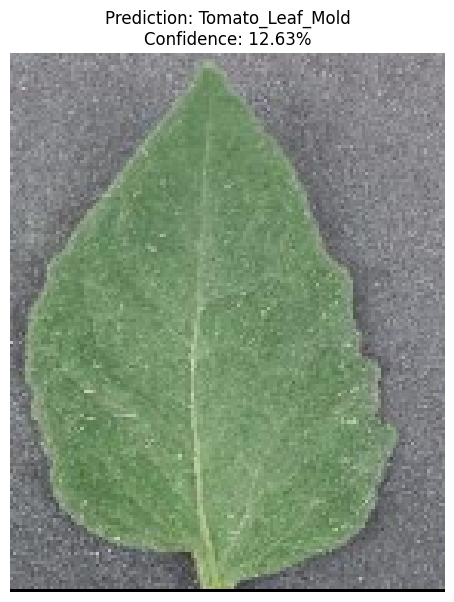

🌿 TOMATO LEAF AI ANALYSIS
Predicted Disease : Tomato_Leaf_Mold
Confidence        : 12.63%

Top 5 Predictions:
------------------------------------------------------------
1. Tomato_Leaf_Mold                              12.63%
2. Tomato_Septoria_leaf_spot                     11.45%
3. Tomato__Target_Spot                           11.05%
4. Tomato_Spider_mites_Two_spotted_spider_mite   10.88%
5. Tomato_Late_blight                            10.54%


In [ ]:
# ============================================================
# REAL-WORLD TOMATO LEAF PREDICTION
# ============================================================

from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

IMAGE_PATH = "/content/healthy_tomato.png"

# ------------------------------------------------------------
# Make sure model is in evaluation mode
# ------------------------------------------------------------
model.eval()
model = model.to(device)

# ------------------------------------------------------------
# Load image
# ------------------------------------------------------------
image = Image.open(IMAGE_PATH).convert("RGB")

print("Image loaded successfully!")
print("Image size:", image.size)

# ------------------------------------------------------------
# Use the same transform used during validation/test
# ------------------------------------------------------------
input_tensor = test_dataset.transform(image).unsqueeze(0).to(device)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------
with torch.no_grad():

    output = model(input_tensor)

    probabilities = F.softmax(output, dim=1)

    top_probs, top_indices = torch.topk(
        probabilities,
        k=min(5, len(classes)),
        dim=1
    )

# ------------------------------------------------------------
# Top prediction
# ------------------------------------------------------------
predicted_index = top_indices[0][0].item()
predicted_class = classes[predicted_index]
predicted_confidence = top_probs[0][0].item() * 100

# ------------------------------------------------------------
# Display image
# ------------------------------------------------------------
plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {predicted_confidence:.2f}%"
)

plt.show()

# ------------------------------------------------------------
# Print result
# ------------------------------------------------------------
print("=" * 60)
print("🌿 TOMATO LEAF AI ANALYSIS")
print("=" * 60)

print(f"Predicted Disease : {predicted_class}")
print(f"Confidence        : {predicted_confidence:.2f}%")

print("\nTop 5 Predictions:")
print("-" * 60)

for rank in range(len(top_indices[0])):

    idx = top_indices[0][rank].item()
    prob = top_probs[0][rank].item() * 100

    print(f"{rank+1}. {classes[idx]:45s} {prob:.2f}%")

##**4-IMAGE TOMATO PLANT ANALYZER**

In [ ]:
# ============================================================
# 4-IMAGE TOMATO PLANT ANALYZER
# ============================================================

import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np

def analyze_4_images(image_paths, model, transform, classes, device="cpu"):

    model.eval()
    model.to(device)

    all_probabilities = []
    individual_results = []

    print("=" * 65)
    print("🌿 4-IMAGE TOMATO PLANT ANALYSIS")
    print("=" * 65)

    # --------------------------------------------------------
    # Analyze each image
    # --------------------------------------------------------

    for i, image_path in enumerate(image_paths):

        image = Image.open(image_path).convert("RGB")

        # Same preprocessing used during testing
        tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():

            output = model(tensor)

            probabilities = F.softmax(output, dim=1)

        probabilities = probabilities[0].cpu()

        # Save probabilities for fusion
        all_probabilities.append(probabilities)

        # Individual prediction
        confidence, predicted_idx = torch.max(
            probabilities,
            dim=0
        )

        predicted_class = classes[predicted_idx.item()]
        confidence_percent = confidence.item() * 100

        individual_results.append({
            "image": i + 1,
            "disease": predicted_class,
            "confidence": confidence_percent
        })

        print(f"\n📷 Image {i+1}")
        print(f"Prediction : {predicted_class}")
        print(f"Confidence : {confidence_percent:.2f}%")

    # --------------------------------------------------------
    # Combine all 4 images
    # --------------------------------------------------------

    all_probabilities = torch.stack(all_probabilities)

    # Average probability across all views
    fused_probabilities = torch.mean(
        all_probabilities,
        dim=0
    )

    final_confidence, final_idx = torch.max(
        fused_probabilities,
        dim=0
    )

    final_disease = classes[final_idx.item()]
    final_confidence_percent = final_confidence.item() * 100

    # --------------------------------------------------------
    # Consensus
    # --------------------------------------------------------

    predictions = [
        result["disease"]
        for result in individual_results
    ]

    counts = {}

    for prediction in predictions:
        counts[prediction] = counts.get(prediction, 0) + 1

    consensus_disease = max(
        counts,
        key=counts.get
    )

    consensus_count = counts[consensus_disease]

    # --------------------------------------------------------
    # Top 5 final predictions
    # --------------------------------------------------------

    top_probs, top_indices = torch.topk(
        fused_probabilities,
        k=min(5, len(classes))
    )

    # --------------------------------------------------------
    # Final result
    # --------------------------------------------------------

    print("\n" + "=" * 65)
    print("🎯 FINAL PLANT RESULT")
    print("=" * 65)

    print(f"Final Disease       : {final_disease}")
    print(f"Combined Confidence : {final_confidence_percent:.2f}%")
    print(
        f"Consensus            : "
        f"{consensus_count}/4 images"
    )

    print("\nTop 5 Combined Predictions:")
    print("-" * 65)

    for rank in range(len(top_indices)):

        idx = top_indices[rank].item()
        prob = top_probs[rank].item() * 100

        print(
            f"{rank+1}. "
            f"{classes[idx]:45s} "
            f"{prob:.2f}%"
        )

    # --------------------------------------------------------
    # Reliability flag
    # --------------------------------------------------------

    if consensus_count >= 3:

        reliability = "HIGH"

    elif consensus_count == 2:

        reliability = "MEDIUM"

    else:

        reliability = "LOW"

    print("\nAnalysis Reliability:", reliability)

    if reliability == "LOW":

        print(
            "⚠️ Images disagree strongly. "
            "Retake images from different angles."
        )

    print("=" * 65)

    return {
        "individual_results": individual_results,
        "final_disease": final_disease,
        "combined_confidence": final_confidence_percent,
        "consensus": f"{consensus_count}/4",
        "reliability": reliability,
        "probabilities": fused_probabilities
    }

In [ ]:
image_paths = [
    "//content/1a1184f8-c414-4ead-a4c4-41ae78e29a82___RS_HL 1971.JPG",
    "/content/1b434c52-7be4-40c4-90d5-13220f1a3eba___RS_HL 5418.JPG",
    "/content/2ccb9ee9-faac-4d32-9af5-29497fa2e028___RS_HL 1837.JPG",
    "/content/2dee1571-ef6b-40ef-8c46-334e89aad3f1___RS_HL 1950.JPG"
]

result = analyze_4_images(
    image_paths,
    model,
    test_dataset.transform,
    classes,
    device
)

🌿 4-IMAGE TOMATO PLANT ANALYSIS

📷 Image 1
Prediction : Tomato_Leaf_Mold
Confidence : 13.53%

📷 Image 2
Prediction : Tomato_Leaf_Mold
Confidence : 14.98%

📷 Image 3
Prediction : Tomato_Leaf_Mold
Confidence : 12.76%

📷 Image 4
Prediction : Tomato_Leaf_Mold
Confidence : 12.66%

🎯 FINAL PLANT RESULT
Final Disease       : Tomato_Leaf_Mold
Combined Confidence : 13.48%
Consensus            : 4/4 images

Top 5 Combined Predictions:
-----------------------------------------------------------------
1. Tomato_Leaf_Mold                              13.48%
2. Tomato__Target_Spot                           11.10%
3. Tomato_Spider_mites_Two_spotted_spider_mite   10.32%
4. Tomato_Late_blight                            10.29%
5. Tomato_Bacterial_spot                         10.19%

Analysis Reliability: HIGH


In [ ]:
# ============================================================
# TOMATO LEAF - AFFECTED AREA ESTIMATION
# Prototype / Visual Estimation
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def estimate_affected_area(image_path):

    # Load image
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # --------------------------------------------------------
    # 1. Convert to HSV
    # --------------------------------------------------------

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # --------------------------------------------------------
    # 2. Detect approximate green leaf region
    # --------------------------------------------------------

    lower_green = np.array([25, 30, 20])
    upper_green = np.array([95, 255, 255])

    leaf_mask = cv2.inRange(
        hsv,
        lower_green,
        upper_green
    )

    # Remove small noise
    kernel = np.ones((5, 5), np.uint8)

    leaf_mask = cv2.morphologyEx(
        leaf_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    leaf_mask = cv2.morphologyEx(
        leaf_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # --------------------------------------------------------
    # 3. Detect suspicious/damaged regions
    #
    # Brown/yellow/dark regions are treated as
    # potential disease regions.
    # --------------------------------------------------------

    # Brown / yellow / dark pixels
    lower_damage = np.array([5, 30, 20])
    upper_damage = np.array([45, 255, 220])

    damage_mask = cv2.inRange(
        hsv,
        lower_damage,
        upper_damage
    )

    # Only count damage INSIDE leaf region
    damage_mask = cv2.bitwise_and(
        damage_mask,
        leaf_mask
    )

    # Remove small noise
    damage_mask = cv2.morphologyEx(
        damage_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    damage_mask = cv2.morphologyEx(
        damage_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # --------------------------------------------------------
    # 4. Calculate area
    # --------------------------------------------------------

    leaf_pixels = np.sum(leaf_mask > 0)
    affected_pixels = np.sum(damage_mask > 0)

    if leaf_pixels == 0:
        affected_area = 0.0
    else:
        affected_area = (
            affected_pixels / leaf_pixels
        ) * 100

    # --------------------------------------------------------
    # 5. Severity
    # --------------------------------------------------------

    if affected_area < 5:
        severity = "Healthy / Very Low"

    elif affected_area < 15:
        severity = "Low"

    elif affected_area < 30:
        severity = "Moderate"

    elif affected_area < 50:
        severity = "High"

    else:
        severity = "Very High"

    # --------------------------------------------------------
    # 6. Visualization
    # --------------------------------------------------------

    overlay = image_rgb.copy()

    overlay[damage_mask > 0] = [255, 0, 0]

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(leaf_mask, cmap="gray")
    plt.title("Leaf Region")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(
        f"Affected Area: {affected_area:.2f}%\n"
        f"Severity: {severity}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Result
    # --------------------------------------------------------

    print("=" * 60)
    print("🌿 TOMATO LEAF SEVERITY ANALYSIS")
    print("=" * 60)

    print(f"Leaf Area Pixels     : {leaf_pixels:,}")
    print(f"Affected Pixels      : {affected_pixels:,}")
    print(f"Affected Area        : {affected_area:.2f}%")
    print(f"Severity             : {severity}")

    return {
        "affected_area_percent": affected_area,
        "severity": severity,
        "leaf_pixels": int(leaf_pixels),
        "affected_pixels": int(affected_pixels)
    }

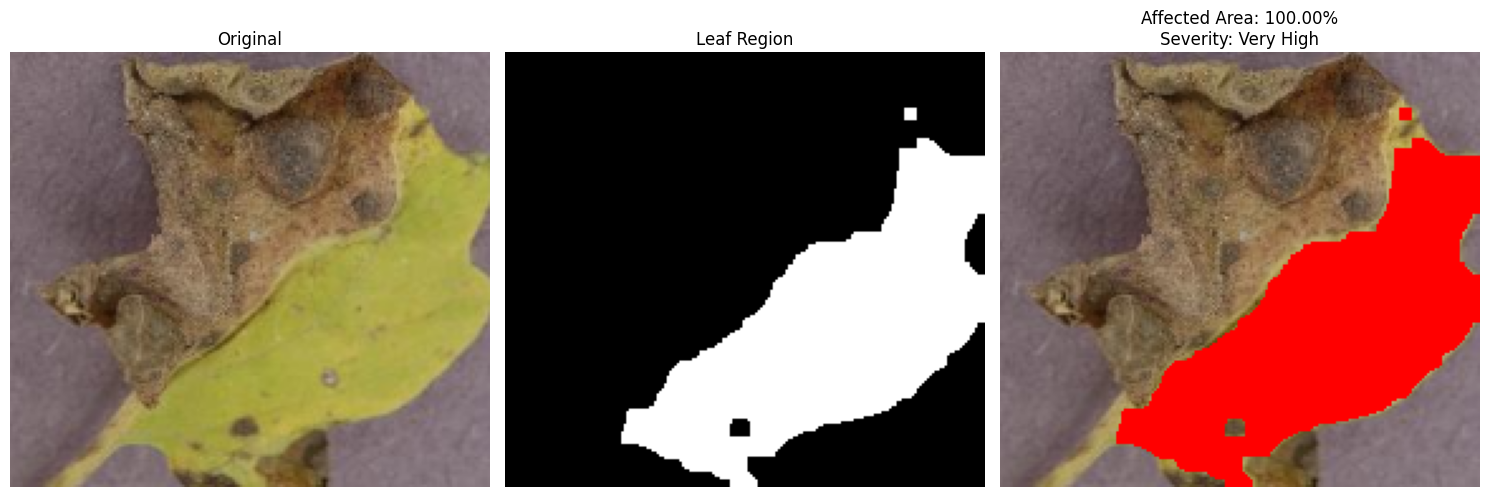

🌿 TOMATO LEAF SEVERITY ANALYSIS
Leaf Area Pixels     : 8,866
Affected Pixels      : 8,866
Affected Area        : 100.00%
Severity             : Very High


In [ ]:
result = estimate_affected_area(
    "/content/leaf6.png"
)

In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 19.2 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py --server.address 0.0.0.0 --server.port 8501 > /content/streamlit.log 2>&1 &

In [ ]:
!ls -lh app.py

-rw-r--r-- 1 root root 24K Aug 15 06:06 app.py


In [ ]:
!streamlit run app.py &>/content/streamlit.log &

In [ ]:
!pkill -f ngrok || true

^C


In [ ]:
!ps aux | grep streamlit

root        6050  7.9  0.5 525440 71860 ?        Sl   06:06   0:02 /usr/bin/python3 /usr/local/bin/streamlit run app.py --server.address 0.0.0.0 --server.port 8501
root        6116 12.5  0.5 523376 69876 ?        Sl   06:06   0:01 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root        6183  0.0  0.0   7372  3376 ?        S    06:06   0:00 /bin/bash -c ps aux | grep streamlit
root        6185  0.0  0.0   6480  2424 ?        S    06:06   0:00 grep streamlit


In [ ]:
!cat /content/streamlit.log



2026-08-15 06:06:34.227 Uvicorn server started on :::8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://136.107.45.218:8502



In [ ]:
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
date: Sat, 15 Aug 2026 06:06:51 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 10951
last-modified: Sat, 15 Aug 2026 06:03:55 GMT
etag: "3d06bc145d263f86d3e24c21a015bc2c"
cache-control: no-cache



In [ ]:
from pyngrok import ngrok

ngrok.kill()

ngrok.set_auth_token(" USE YOUR TOKEN KEY")

tunnel = ngrok.connect(
    addr=8501,
    proto="http"
)

print(tunnel.public_url)

https://emotion-snowsuit-splice.ngrok-free.dev
